<a href="https://colab.research.google.com/github/Sanika-tech123/Deep-Learning-Lab/blob/main/DL_9_Temperature_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving DailyDelhiClimateTrain.csv to DailyDelhiClimateTrain.csv
Dataset Loaded Successfully

         date   meantemp   humidity  wind_speed  meanpressure
0  2013-01-01  10.000000  84.500000    0.000000   1015.666667
1  2013-01-02   7.400000  92.000000    2.980000   1017.800000
2  2013-01-03   7.166667  87.000000    4.633333   1018.666667
3  2013-01-04   8.666667  71.333333    1.233333   1017.166667
4  2013-01-05   6.000000  86.833333    3.700000   1016.500000

Dataset Shape: (1462, 5)

Dataset Columns:
Index(['date', 'meantemp', 'humidity', 'wind_speed', 'meanpressure'], dtype='object')


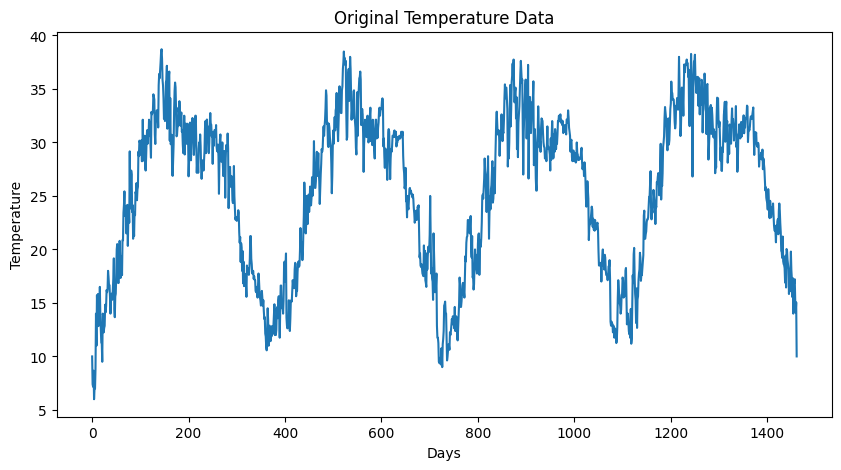


Input Shape for RNN: (1461, 1, 1)
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3812
Epoch 2/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1430
Epoch 3/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0457
Epoch 4/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0204
Epoch 5/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0160
Epoch 6/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0148
Epoch 7/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0140
Epoch 8/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0131
Epoch 9/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0123
Epoch 10/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0115
Epoch 11/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0107
Epoch 12/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0099
Epoch 13/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0092
Epoch 14/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0084
Epoch 15/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0077
Epoch 16/20
46/46 ━━━━━━━━━━━━

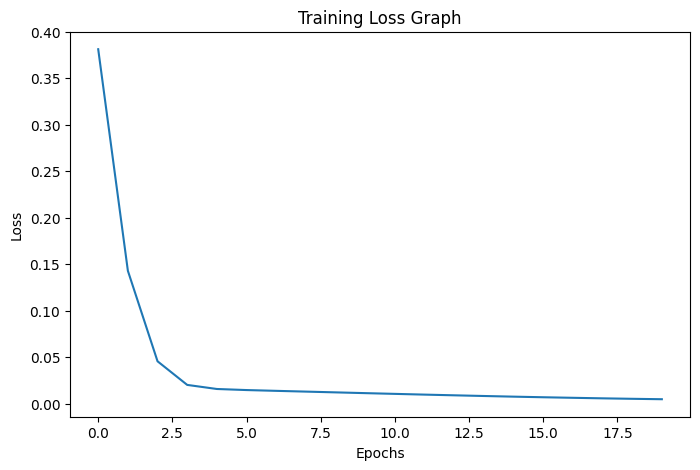

In [ ]:
# ===================================================
# Temperature Forecasting Using RNN
# ===================================================

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN
from tensorflow.keras.layers import Dense

# ===================================================
# Upload Dataset File in Google Colab
# ===================================================

from google.colab import files

uploaded = files.upload()

# ===================================================
# Load Dataset
# ===================================================

data = pd.read_csv("DailyDelhiClimateTrain.csv")

print("Dataset Loaded Successfully\n")

# Show first 5 rows
print(data.head())

# ===================================================
# Show Dataset Information
# ===================================================

print("\nDataset Shape:", data.shape)

print("\nDataset Columns:")
print(data.columns)

# ===================================================
# Select Temperature Column
# ===================================================

temperature = data['meantemp'].values

# ===================================================
# Plot Original Temperature Data
# ===================================================

plt.figure(figsize=(10,5))

plt.plot(temperature)

plt.title("Original Temperature Data")

plt.xlabel("Days")

plt.ylabel("Temperature")

plt.show()

# ===================================================
# Normalize Data
# ===================================================

scaler = MinMaxScaler()

temperature = scaler.fit_transform(
    temperature.reshape(-1,1)
)

# ===================================================
# Prepare Dataset
# ===================================================

X = []
y = []

for i in range(len(temperature)-1):

    X.append(temperature[i])

    y.append(temperature[i+1])

# Convert into numpy arrays
X = np.array(X)
y = np.array(y)

# ===================================================
# Reshape Data for RNN
# ===================================================

X = X.reshape((X.shape[0], 1, 1))

print("\nInput Shape for RNN:", X.shape)

# ===================================================
# Build RNN Model
# ===================================================

model = Sequential()

# RNN Layer
model.add(SimpleRNN(
    10,
    activation='relu',
    input_shape=(1,1)
))

# Output Layer
model.add(Dense(1))

# ===================================================
# Compile Model
# ===================================================

model.compile(
    optimizer='adam',
    loss='mse'
)

# ===================================================
# Train Model
# ===================================================

history = model.fit(
    X,
    y,
    epochs=20
)

print("\nModel Trained Successfully")

# ===================================================
# Predict Temperatures
# ===================================================

prediction = model.predict(X[:5])

# Convert prediction back to original values
prediction = scaler.inverse_transform(prediction)

print("\nPredicted Temperatures:\n")

print(prediction)

# ===================================================
# Plot Training Loss Graph
# ===================================================

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])

plt.title("Training Loss Graph")

plt.xlabel("Epochs")

plt.ylabel("Loss")

plt.show()